Node      Iteratif (detik)    Rekursif (detik)    
10        0.000012            0.000009            
50        0.000111            0.000206            
100       0.000156            0.000582            
200       0.000702            0.002925            
500       0.003476            0.013604            
1000      0.009410            0.071695            
2000      0.033035            0.278553            
5000      0.196287            1.456017            
10000     1.316121            6.818328            


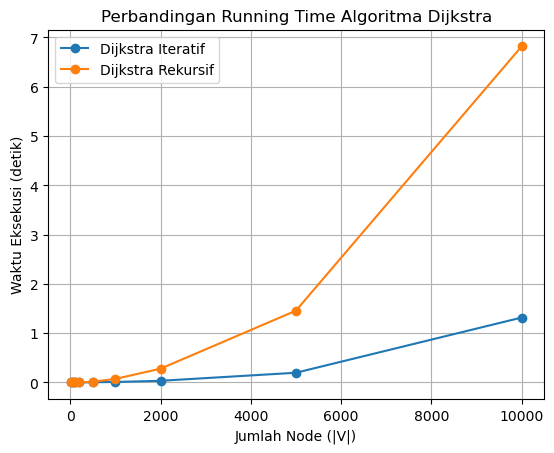

In [25]:
import random
import time
import heapq
import matplotlib.pyplot as plt
import sys

# =========================
# BATASI REKURSIF PYTHON
# =========================
sys.setrecursionlimit(20000)

# =========================
# GENERATE GRAF OTOMATIS
# =========================
def generate_graph(num_nodes, density=0.1, max_weight=10):
    graph = {i: {} for i in range(num_nodes)}

    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if random.random() < density:
                weight = random.randint(1, max_weight)
                graph[i][j] = weight
                graph[j][i] = weight

    return graph


# =========================
# DIJKSTRA ITERATIF
# =========================
def dijkstra_iterative(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    pq = [(0, start)]

    while pq:
        current_dist, current_node = heapq.heappop(pq)

        if current_dist > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            new_dist = current_dist + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                heapq.heappush(pq, (new_dist, neighbor))

    return distances


# =========================
# DIJKSTRA REKURSIF
# =========================
def dijkstra_recursive(graph, distances, visited, current):
    visited.add(current)

    for neighbor, weight in graph[current].items():
        if neighbor not in visited:
            new_dist = distances[current] + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist

    min_node = None
    min_dist = float('inf')

    for node in graph:
        if node not in visited and distances[node] < min_dist:
            min_dist = distances[node]
            min_node = node

    if min_node is not None:
        dijkstra_recursive(graph, distances, visited, min_node)


def run_dijkstra_recursive(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    visited = set()
    dijkstra_recursive(graph, distances, visited, start)
    return distances


# =========================
# EKSPERIMEN RUNNING TIME
# =========================
def run_experiment():
    sizes = [10, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
    iter_times = []
    rec_times = []

    print("=" * 65)
    print(f"{'Node':<10}{'Iteratif (detik)':<20}{'Rekursif (detik)':<20}")
    print("=" * 65)

    for n in sizes:
        graph = generate_graph(n)

        start = time.perf_counter()
        dijkstra_iterative(graph, 0)
        iter_time = time.perf_counter() - start

        start = time.perf_counter()
        run_dijkstra_recursive(graph, 0)
        rec_time = time.perf_counter() - start

        iter_times.append(iter_time)
        rec_times.append(rec_time)

        print(f"{n:<10}{iter_time:<20.6f}{rec_time:<20.6f}")

    print("=" * 65)
    return sizes, iter_times, rec_times


# =========================
# MAIN + GRAFIK
# =========================
sizes, iter_times, rec_times = run_experiment()

plt.plot(sizes, iter_times, marker='o', label="Dijkstra Iteratif")
plt.plot(sizes, rec_times, marker='o', label="Dijkstra Rekursif")

plt.xlabel("Jumlah Node (|V|)")
plt.ylabel("Waktu Eksekusi (detik)")
plt.title("Perbandingan Running Time Algoritma Dijkstra")
plt.legend()
plt.grid(True)
plt.show()